# Import thư viện

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

# Load dữ liệu

In [2]:
# Đọc dữ liệu
df = pd.read_csv("../data/live/sales_dashboard.csv")

print("Kích thước dataset:", df.shape)
print("\nThông tin dữ liệu:")
print(df.info())

print("\n5 dòng đầu:")
print(df.head())

Kích thước dataset: (89673, 12)

Thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89673 entries, 0 to 89672
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  89673 non-null  object 
 1   order_purchase_timestamp  89673 non-null  object 
 2   price                     89673 non-null  float64
 3   freight_value             89673 non-null  float64
 4   order_status              89673 non-null  object 
 5   seller_id                 89673 non-null  object 
 6   customer_unique_id        89673 non-null  object 
 7   customer_city             89673 non-null  object 
 8   customer_state            89673 non-null  object 
 9   product_category_name     89673 non-null  object 
 10  Category_VN               89673 non-null  object 
 11  product_id                89673 non-null  object 
dtypes: float64(2), object(10)
memory usage: 8.2+ MB
None

5 dòng đầu

# Kiểm tra missing values

In [3]:

missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_df.sort_values("Missing %", ascending=False)

,Missing Count,Missing %
order_id,0,0.0
order_purchase_timestamp,0,0.0
price,0,0.0
freight_value,0,0.0
order_status,0,0.0
seller_id,0,0.0
customer_unique_id,0,0.0
customer_city,0,0.0
customer_state,0,0.0
product_category_name,0,0.0


# Kiểm tra trùng lặp

In [6]:
print("\nSố dòng trùng:", df.duplicated().sum())
print("Số order_id khác nhau:", df["order_id"].nunique())


Số dòng trùng: 0
Số order_id khác nhau: 86380


# Chuyển đổi kiểu dữ liệu

In [4]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])

df["date"] = df["order_purchase_timestamp"].dt.date
df["month"] = df["order_purchase_timestamp"].dt.to_period("M")
df["year"] = df["order_purchase_timestamp"].dt.year

df.head()

,order_id,order_purchase_timestamp,price,freight_value,order_status,seller_id,customer_unique_id,customer_city,customer_state,product_category_name,Category_VN,product_id,date,month,year
0,2e7a8482f6fb09756ca50c10d7bfc047,2016-09-04 21:15:19,39.99,31.67,shipped,1554a68530182680ad5c8b042c3ab563,b7d76e111c89f7ebf14761390f0f7d17,boa vista,RR,moveis_decoracao,Nội thất & Trang trí,c1488892604e4ba5cff5b4eb4d595400,2016-09-04,2016-09,2016
1,2e7a8482f6fb09756ca50c10d7bfc047,2016-09-04 21:15:19,32.90,31.67,shipped,1554a68530182680ad5c8b042c3ab563,b7d76e111c89f7ebf14761390f0f7d17,boa vista,RR,moveis_decoracao,Nội thất & Trang trí,f293394c72c9b5fafd7023301fc21fc2,2016-09-04,2016-09,2016
2,bfbd0f9bdef84302105ad712db648a6c,2016-09-15 12:16:38,44.99,2.83,delivered,ecccfa2bb93b34a3bf033cc5d1dcdc69,830d5b7aaa3b6f1e9ad63703bec97d23,sao joaquim da barra,SP,beleza_saude,Sức khỏe & Làm đẹp,5a6b04657a4c5ee34285d1e4619a96b4,2016-09-15,2016-09,2016
3,3b697a20d9e427646d92567910af6d57,2016-10-03 09:44:50,29.90,15.56,delivered,522620dcb18a6b31cd7bdf73665113a9,32ea3bdedab835c3aa6cb68ce66565ef,sao paulo,SP,relogios_presentes,Đồng hồ & Quà tặng,3ae08df6bcbfe23586dd431c40bddbb7,2016-10-03,2016-10,2016
4,be5bc2f0da14d8071e2d45451ad119d9,2016-10-03 16:56:50,21.90,17.19,delivered,f09b760d23495ac9a7e00d29b769007c,2f64e403852e6893ae37485d5fcacdaf,panambi,RS,esporte_lazer,Thể thao & Giải trí,fd7fd78fd3cbc1b0a6370a7909c0a629,2016-10-03,2016-10,2016


# Doanh thu

***Tính total revenue mỗi order***

In [65]:
order_summary = df.groupby("order_id").agg({
    "price": "sum",
    "freight_value": "first",  # Sử dụng "first" vì freight_value là per-order, không "sum"
    "order_purchase_timestamp": "first",
    "order_status": "first",
    "customer_unique_id": "first",
    "customer_city": "first",
    "customer_state": "first",
    "month": "first",
    "year": "first"
}).reset_index()

order_summary["order_revenue"] = (
    order_summary["price"] +
    order_summary["freight_value"]
)
order_summary.head()

,order_id,price,freight_value,order_purchase_timestamp,order_status,customer_unique_id,customer_city,customer_state,month,year,order_revenue
0,00010242fe8c5a6d1ba2dd792cb16214,58.9,13.29,2017-09-13 08:59:02,delivered,871766c5855e863f6eccc05f988b23cb,campos dos goytacazes,RJ,2017-09,2017,72.19
1,00018f77f2f0320c557190d7a144bdd3,239.9,19.93,2017-04-26 10:53:06,delivered,eb28e67c4c0b83846050ddfb8a35d051,santa fe do sul,SP,2017-04,2017,259.83
2,000229ec398224ef6ca0657da4fc703e,199.0,17.87,2018-01-14 14:33:31,delivered,3818d81c6709e39d06b2738a8d3a2474,para de minas,MG,2018-01,2018,216.87
3,00042b26cf59d7ce69dfabb4e55b4fd9,199.9,18.14,2017-02-04 13:57:51,delivered,64b576fb70d441e8f1b2d7d446e483c5,varzea paulista,SP,2017-02,2017,218.04
4,00048cc3ae777c65dbb7d2a0634bc1ea,21.9,12.69,2017-05-15 21:42:34,delivered,85c835d128beae5b4ce8602c491bf385,uberaba,MG,2017-05,2017,34.59


***Tổng quan doanh thu***

In [62]:
total_revenue = order_summary["order_revenue"].sum()
total_orders = df["order_id"].nunique()
avg_order_value = total_revenue / total_orders

print("Total Revenue:", total_revenue)
print("Total Orders:", total_orders)
print("Average Order Value:", round(avg_order_value,2))

Total Revenue: 12837295.030000001
Total Orders: 86380
Average Order Value: 148.61


***Doanh thu theo năm***

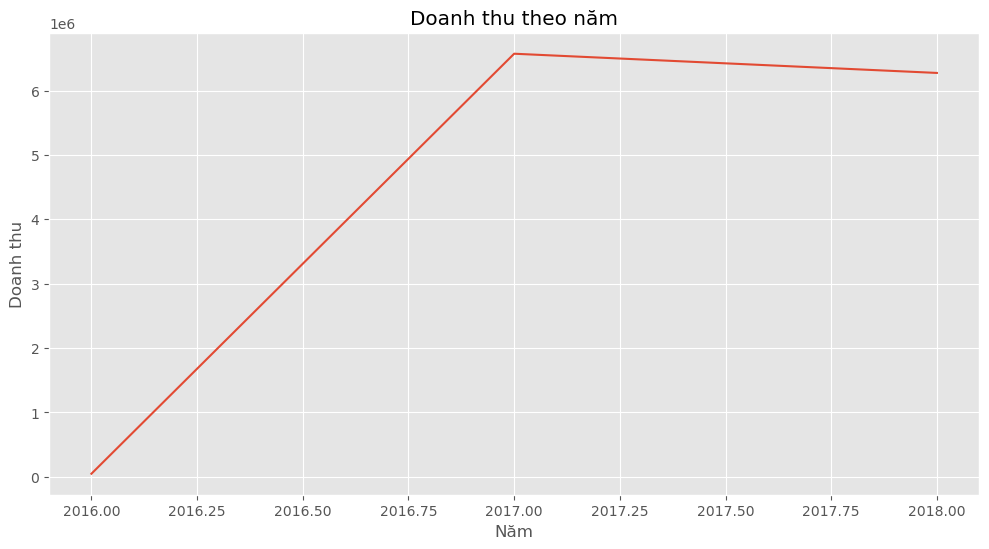

In [33]:
yearly_revenue = order_summary.groupby("year")["order_revenue"].sum()

plt.figure(figsize=(12,6))
yearly_revenue.plot()
plt.title("Doanh thu theo năm")
plt.xlabel("Năm")
plt.ylabel("Doanh thu")
plt.show()

***Doanh thu 12 tháng gần nhất***

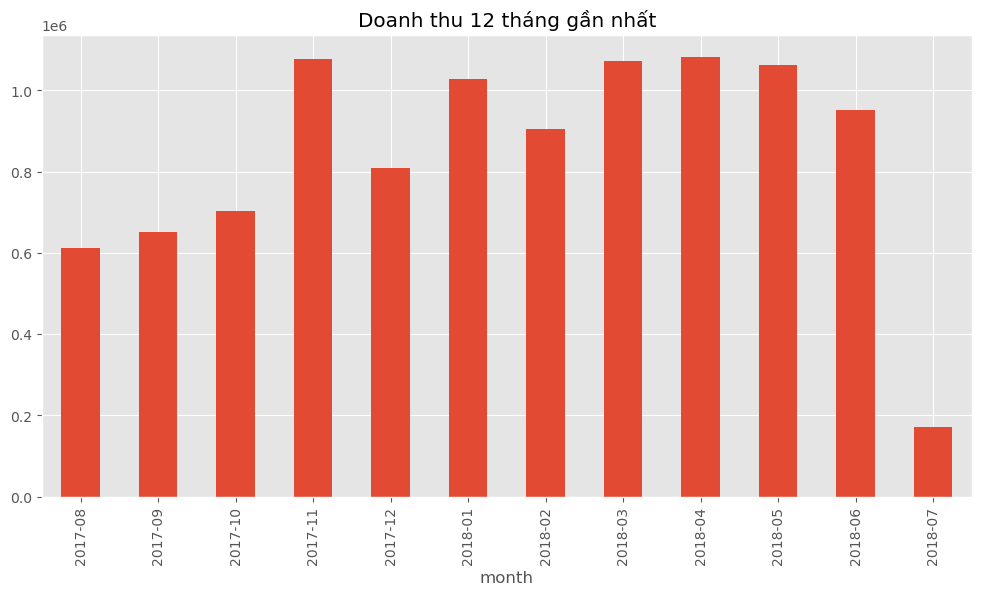

In [37]:
monthly_revenue = order_summary.groupby("month")["order_revenue"].sum()

last_12_months = monthly_revenue.tail(12)

plt.figure(figsize=(12,6))
last_12_months.plot(kind="bar")
plt.title("Doanh thu 12 tháng gần nhất")
plt.show()

***Doanh thu 30 ngày gần nhất***

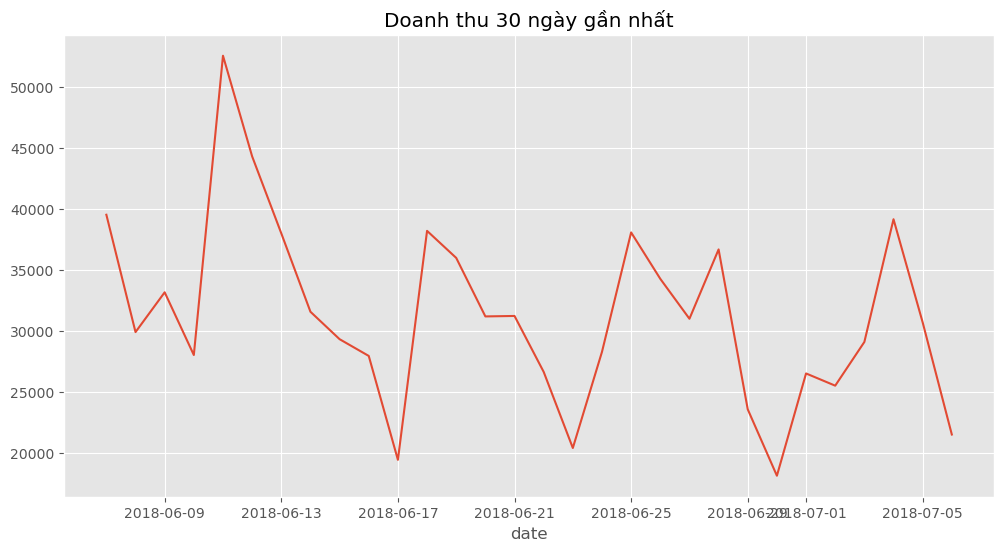

In [39]:
daily_revenue = order_summary.groupby("date")["order_revenue"].sum()
last_30_days = daily_revenue.tail(30)

plt.figure(figsize=(12,6))
last_30_days.plot()
plt.title("Doanh thu 30 ngày gần nhất")
plt.show()

***Top 10 danh mục có doanh thu cao nhất***

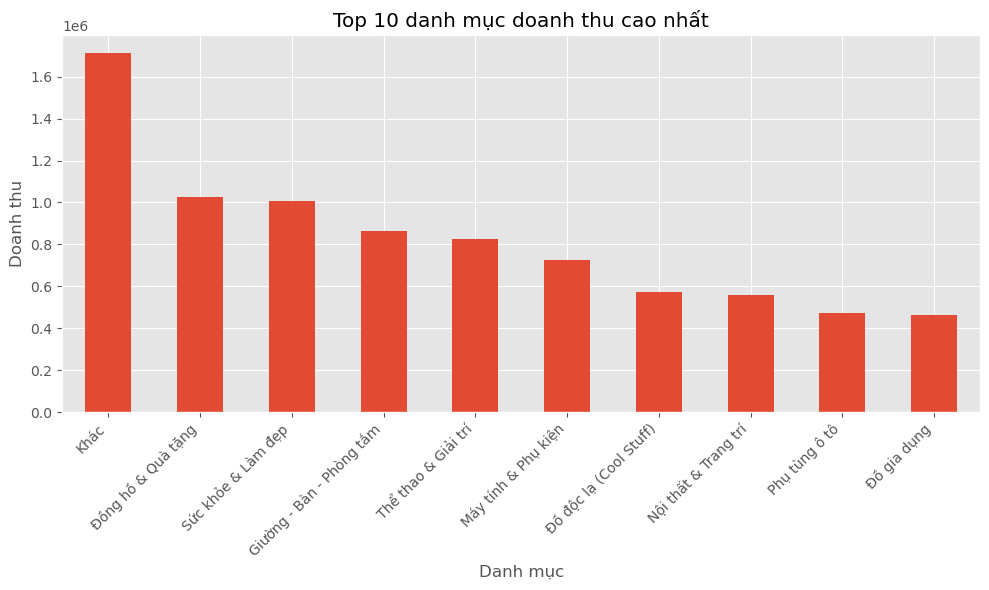

In [70]:
top_category = (
    df.groupby("Category_VN")["price"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_category.plot(kind="bar")
plt.title("Top 10 danh mục doanh thu cao nhất")
plt.xlabel("Danh mục")
plt.ylabel("Doanh thu")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

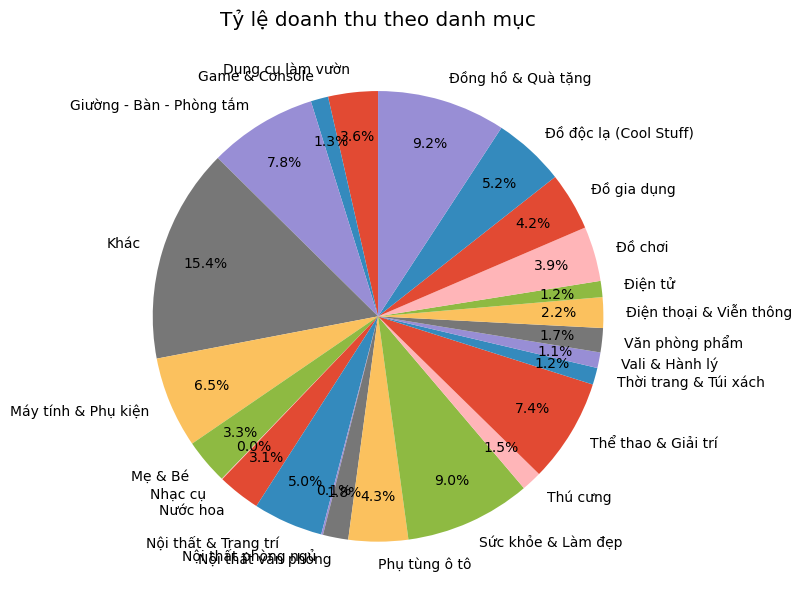

In [71]:
# tính doanh thu theo danh mục và vẽ biểu đồ tỷ lệ
category_revenue = df.groupby("Category_VN")["price"].sum()

plt.figure(figsize=(8,8))
category_revenue.plot(
    kind="pie",
    autopct="%1.1f%%",
    pctdistance=0.8,
    startangle=90,
    ylabel=""
)
plt.title("Tỷ lệ doanh thu theo danh mục")
plt.tight_layout()
plt.show()

***Top 10 bang có doanh thu cao nhất***

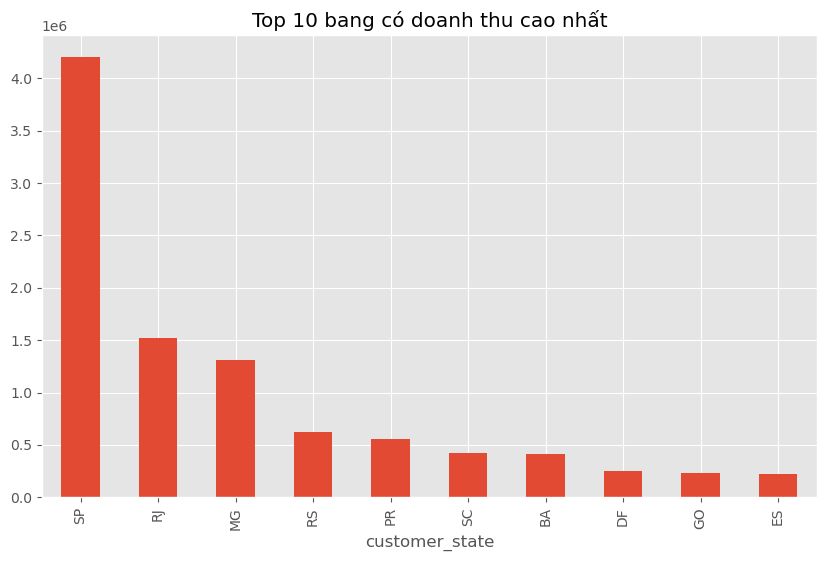

In [72]:
state_revenue = df.groupby("customer_state")["price"].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
state_revenue.head(10).plot(kind="bar")
plt.title("Top 10 bang có doanh thu cao nhất")
plt.show()

***Tổng số khách hàng***

In [73]:
unique_customers = df["customer_unique_id"].nunique()
print("Số khách hàng:", unique_customers)

Số khách hàng: 83572


***Top 10 sản phẩm bán chạy***

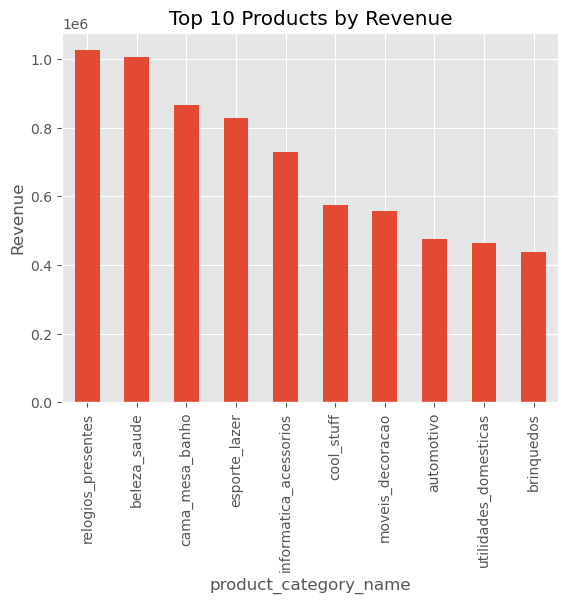

product_category_name
relogios_presentes        1024838.62
beleza_saude              1005866.41
cama_mesa_banho            864834.39
esporte_lazer              827218.19
informatica_acessorios     727855.20
cool_stuff                 573809.39
moveis_decoracao           557400.19
automotivo                 474736.92
utilidades_domesticas      463007.72
brinquedos                 436858.33
Name: price, dtype: float64

In [74]:
top_products = df.groupby("product_category_name")["price"].sum().sort_values(ascending=False).head(10)

plt.figure()
top_products.plot(kind="bar")
plt.title("Top 10 Products by Revenue")
plt.ylabel("Revenue")
plt.show()

top_products

# Hiệu suất

In [78]:
order_seller = df.groupby(["order_id", "seller_id"]).agg({
    "price": "sum"
}).reset_index()

# Rename để dễ hiểu
order_seller.rename(columns={"price": "seller_revenue"}, inplace=True)

In [83]:
seller_performance = order_seller.groupby("seller_id").agg({
    "order_id": "nunique",
    "seller_revenue": ["sum", "mean"]
}).round(2)

seller_performance.columns = [
    "Total Orders",
    "Total Revenue",
    "Avg Revenue per Order"
]

# Sắp xếp theo doanh thu
seller_performance = seller_performance.sort_values(
    "Total Revenue", ascending=False
).head(10)

# Thêm cột Rank (1 → 10)
seller_performance.insert(
    0,
    "Rank",
    range(1, len(seller_performance) + 1)
)

seller_performance

,Rank,Total Orders,Total Revenue,Avg Revenue per Order
seller_id,,,,
4869f7a5dfa277a7dca6462dcf3b52b2,1,1003,205841.04,205.23
53243585a1d6dc2643021fd1853d8905,2,270,188405.59,697.80
4a3ca9315b744ce9f8e9374361493884,3,1690,180487.02,106.80
fa1c13f2614d7b5c4749cbc52fecda94,4,518,173016.77,334.01
7e93a43ef30c4f03f38b393420bc753a,5,324,169937.46,524.50
da8622b14eb17ae2831f4ac5b9dab84a,6,1204,138154.72,114.75
7a67c85e85bb2ce8582c35f2203ad736,7,1123,137824.95,122.73
7c67e1448b00f6e969d365cea6b010ab,8,936,136853.27,146.21
46dc3b2cc0980fb8ec44634e21d2718e,9,504,121321.48,240.72
